<a href="https://colab.research.google.com/github/Kaifcse/Prodigy-InfoTech-DataScience-Internship/blob/main/Prodigy_DS_04/Twitter_Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install wordcloud nltk

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

import re

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [4]:
train_df = pd.read_csv(
    'twitter_training.csv',
    header=None
)

valid_df = pd.read_csv(
    'twitter_validation.csv',
    header=None
)

In [5]:
train_df.columns = [
    'ID',
    'Brand',
    'Sentiment',
    'Tweet'
]

valid_df.columns = [
    'ID',
    'Brand',
    'Sentiment',
    'Tweet'
]

In [6]:
train_df.head()

,ID,Brand,Sentiment,Tweet
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [7]:
train_df.shape

(74682, 4)

In [8]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   ID         74682 non-null  int64 
 1   Brand      74682 non-null  object
 2   Sentiment  74682 non-null  object
 3   Tweet      73996 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB


In [9]:
train_df.dropna(inplace=True)
valid_df.dropna(inplace=True)

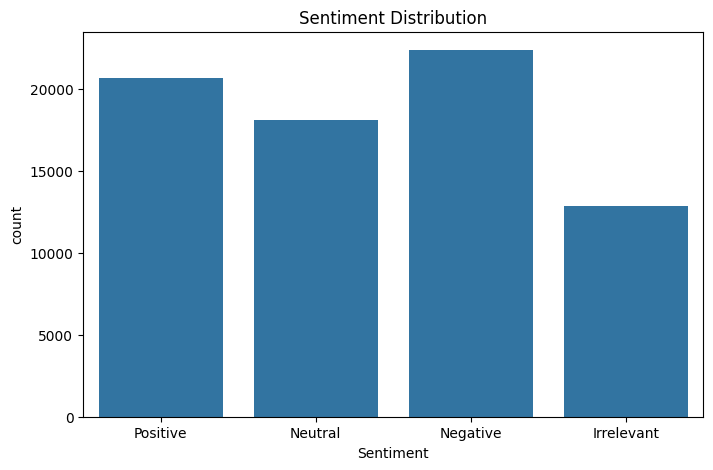

In [10]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Sentiment',
    data=train_df
)

plt.title('Sentiment Distribution')

plt.show()

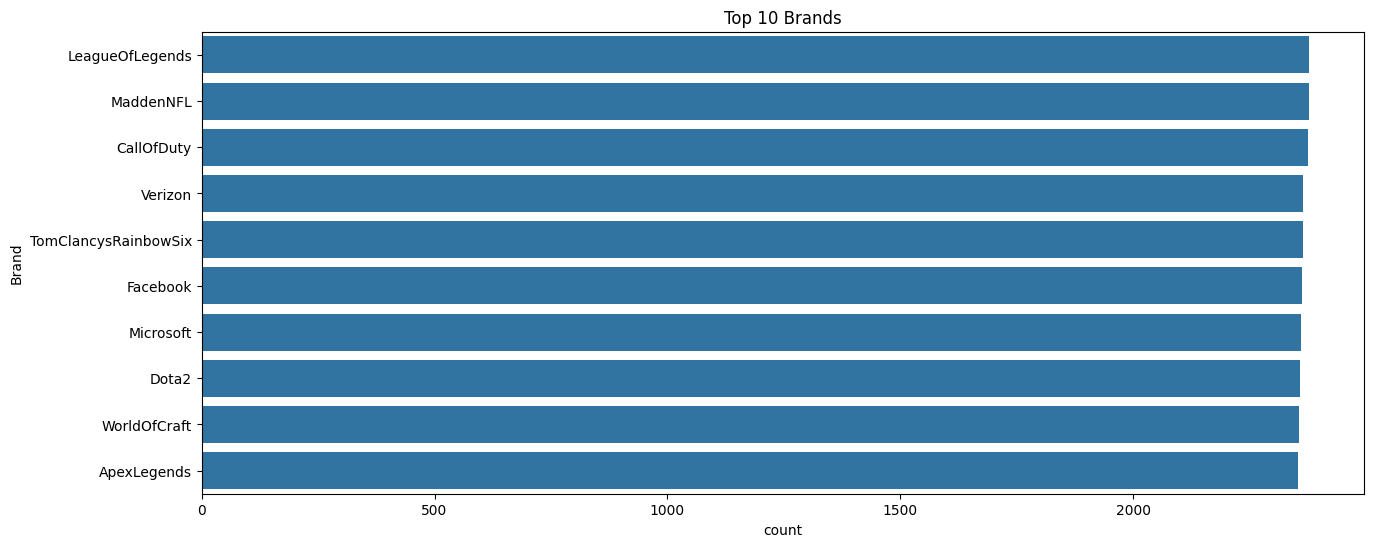

In [11]:
plt.figure(figsize=(15,6))

sns.countplot(
    y='Brand',
    data=train_df,
    order=train_df['Brand'].value_counts().iloc[:10].index
)

plt.title('Top 10 Brands')

plt.show()

In [12]:
stemmer = PorterStemmer()

stop_words = set(stopwords.words('english'))

def clean_text(text):

    text = str(text).lower()

    text = re.sub(r'http\\S+', '', text)

    text = re.sub(r'[^a-zA-Z]', ' ', text)

    words = word_tokenize(text)

    words = [
        stemmer.stem(word)
        for word in words
        if word not in stop_words
    ]

    return ' '.join(words)

In [14]:
nltk.download('punkt_tab')
train_df['Clean_Tweet'] = train_df['Tweet'].apply(clean_text)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


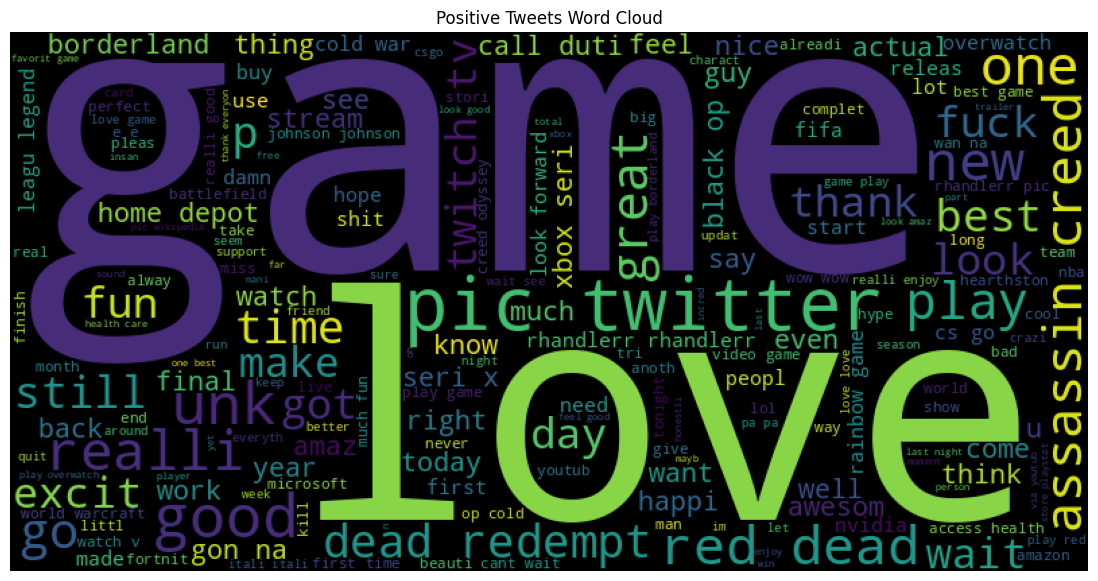

In [15]:
positive_text = ' '.join(
    train_df[
        train_df['Sentiment'] == 'Positive'
    ]['Clean_Tweet']
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='black'
).generate(positive_text)

plt.figure(figsize=(15,7))

plt.imshow(wordcloud)

plt.axis('off')

plt.title('Positive Tweets Word Cloud')

plt.show()

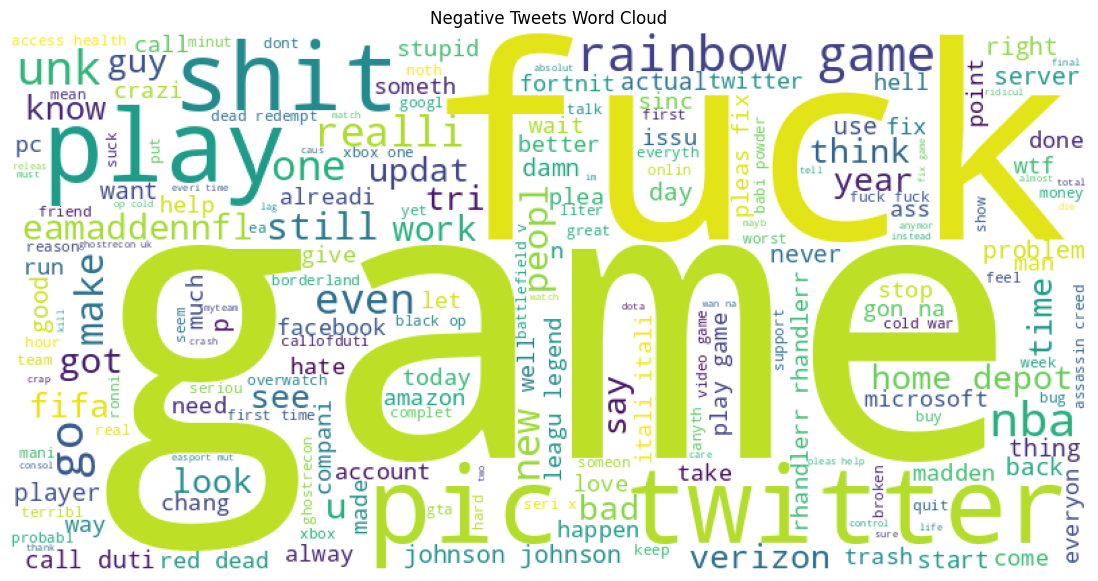

In [16]:
negative_text = ' '.join(
    train_df[
        train_df['Sentiment'] == 'Negative'
    ]['Clean_Tweet']
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(negative_text)

plt.figure(figsize=(15,7))

plt.imshow(wordcloud)

plt.axis('off')

plt.title('Negative Tweets Word Cloud')

plt.show()

In [17]:
vectorizer = TfidfVectorizer(
    max_features=5000
)

X = vectorizer.fit_transform(
    train_df['Clean_Tweet']
)

y = train_df['Sentiment']

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [19]:
model = MultinomialNB()

model.fit(X_train, y_train)

MultinomialNB()

In [20]:
y_pred = model.predict(X_test)

In [21]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

Accuracy: 0.6402702702702703


In [22]:
print(classification_report(
    y_test,
    y_pred
))

              precision    recall  f1-score   support

  Irrelevant       0.75      0.35      0.47      2696
    Negative       0.62      0.81      0.70      4380
     Neutral       0.68      0.53      0.60      3605
    Positive       0.62      0.74      0.67      4119

    accuracy                           0.64     14800
   macro avg       0.67      0.61      0.61     14800
weighted avg       0.66      0.64      0.63     14800



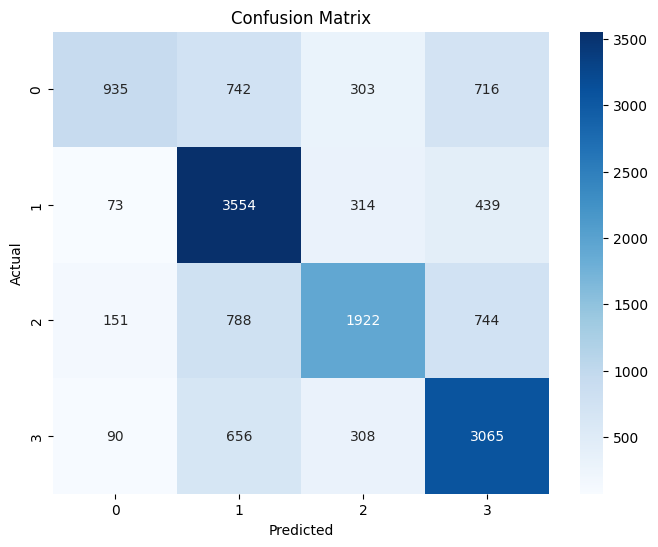

In [23]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix')

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

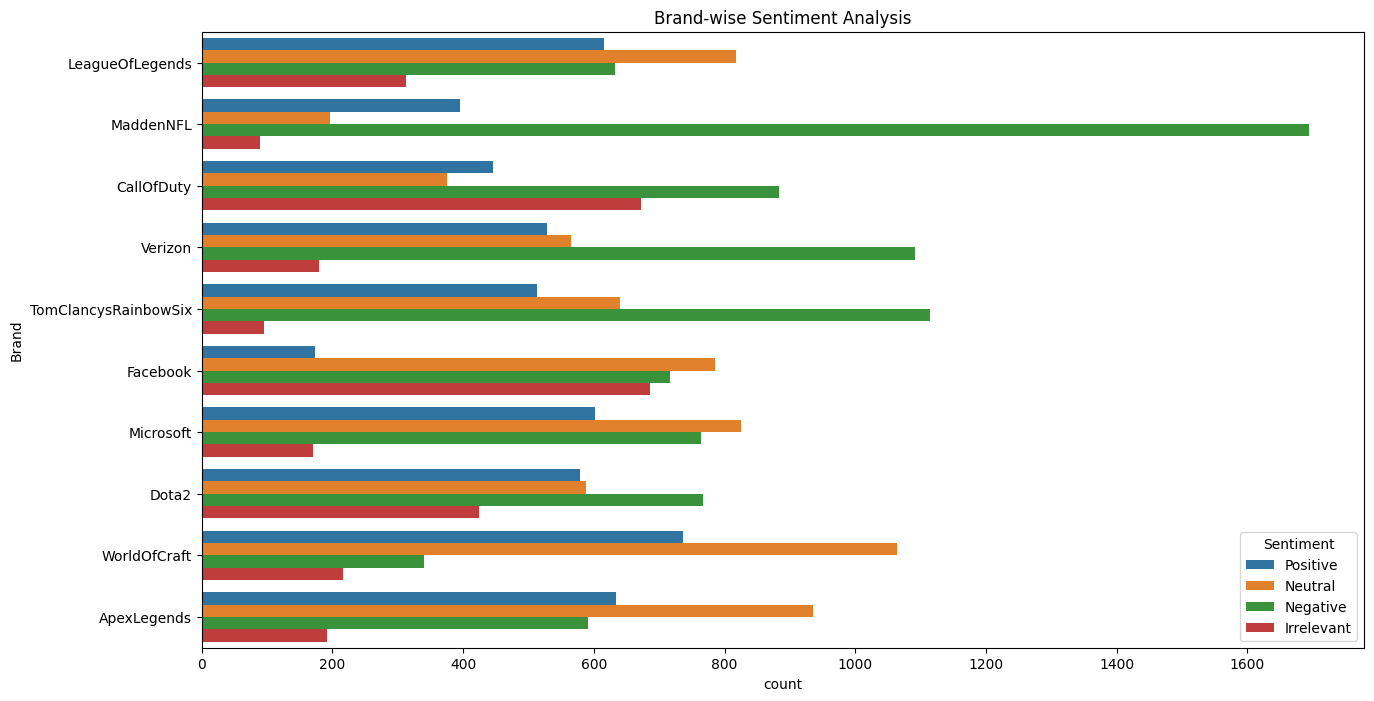

In [24]:
plt.figure(figsize=(15,8))

sns.countplot(
    y='Brand',
    hue='Sentiment',
    data=train_df,
    order=train_df['Brand'].value_counts().iloc[:10].index
)

plt.title('Brand-wise Sentiment Analysis')

plt.show()

# Conclusion

This project performs Sentiment Analysis on Twitter social media data.

The model analyzes user opinions and attitudes towards brands using Natural Language Processing and Machine Learning techniques.

Techniques Used:
- Text Cleaning
- Tokenization
- Stopword Removal
- Stemming
- TF-IDF Vectorization
- Naive Bayes Classification
- Data Visualization

Libraries Used:
- Pandas
- NumPy
- Seaborn
- Matplotlib
- NLTK
- Scikit-learn
- WordCloud